# EDA: `order_reviews`

Разведочный анализ таблицы `order_reviews` из базы данных Olist.


### Импорты

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

### Конфигурация

In [3]:
USERNAME = os.getenv("DB_USERNAME")
PASSWORD = os.getenv("DB_PASSWORD")
HOST = os.getenv("DB_HOST")
PORT = os.getenv("DB_PORT")
DATABASE = os.getenv("DB_NAME")

url = URL.create(
    drivername="postgresql+psycopg2",
    username=USERNAME,
    password=PASSWORD,
    host=HOST,
    port=PORT,
    database=DATABASE,
)

In [4]:
connection = create_engine(url=url)

## Анализ данных


In [5]:
read_sql_query = "SELECT * FROM order_reviews"
df = pd.read_sql(sql=read_sql_query, con=connection)

In [6]:
df.head()

,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_id
0,7bc2406110b926393aa56f80a40eba40,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59,73fc7af87114b39712e6da79b0a377eb
1,80e641a11e56f04c1ad469d5645fdfde,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13,a548910a1c6147796b98fdf73dbeba33
2,228ce5500dc1d8e020d8d1322874b6f0,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24,f9e4b658b201a9f2ecdecbb34bed034b
3,e64fb393e7b32834bb789ff8bb30750e,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06,658677c97b385a9be170737859d3511b
4,f7c4243c7fe1938f181bec41a392bdeb,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53,8e6bfb81e283fa7e4f11123a3fb894f1


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  str           
 1   review_score             99224 non-null  int64         
 2   review_comment_title     99224 non-null  str           
 3   review_comment_message   99224 non-null  str           
 4   review_creation_date     99224 non-null  datetime64[us]
 5   review_answer_timestamp  99224 non-null  datetime64[us]
 6   order_id                 99224 non-null  str           
dtypes: datetime64[us](2), int64(1), str(4)
memory usage: 5.3 MB


In [8]:
df.describe(include='all')

,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_id
count,99224,99224.000000,99224,99224,99224,99224,99224
unique,98410,NaN,4528,36160,NaN,NaN,98673
top,c444278834184f72b1484dfe47de7f97,NaN,NaN,NaN,NaN,NaN,c88b1d1b157a9999ce368f218a407141
freq,3,NaN,87656,58247,NaN,NaN,3
mean,NaN,4.086421,NaN,NaN,2018-01-12 20:49:23.948238,2018-01-16 00:23:56.977938,NaN
min,NaN,1.000000,NaN,NaN,2016-10-02 00:00:00,2016-10-07 18:32:28,NaN
25%,NaN,4.000000,NaN,NaN,2017-09-23 00:00:00,2017-09-27 01:53:27.250000,NaN
50%,NaN,5.000000,NaN,NaN,2018-02-02 00:00:00,2018-02-04 22:41:47.500000,NaN
75%,NaN,5.000000,NaN,NaN,2018-05-16 00:00:00,2018-05-20 12:11:21.500000,NaN
max,NaN,5.000000,NaN,NaN,2018-08-31 00:00:00,2018-10-29 12:27:35,NaN


In [9]:
df.memory_usage(deep=True)

Index                          132
review_id                  8037144
review_score                793792
review_comment_title       5306266
review_comment_message     8274420
review_creation_date        793792
review_answer_timestamp     793792
order_id                   8037144
dtype: int64

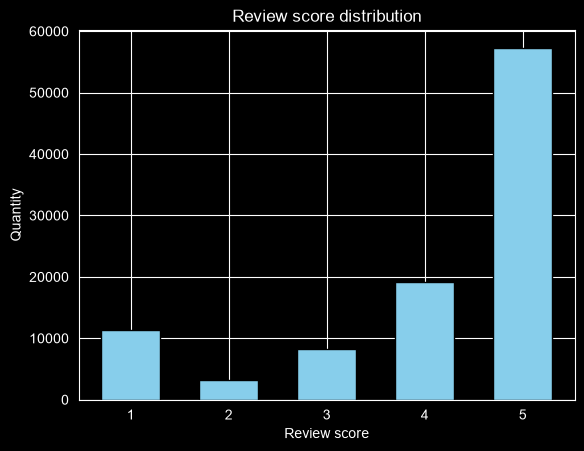

In [10]:
review_score_counts = df['review_score'].value_counts()

plt.bar(review_score_counts.index, review_score_counts.values, color='skyblue', edgecolor='black', width=0.6)

plt.title('Review score distribution')
plt.xlabel('Review score')
plt.ylabel('Quantity')

plt.show()

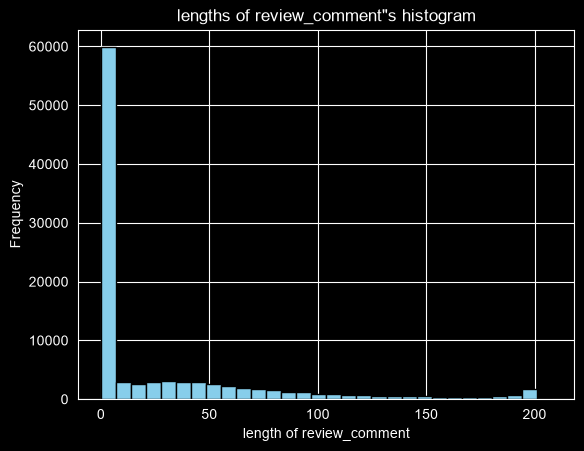

In [11]:
data = df["review_comment_message"].apply(lambda x: len(x) if x != "NaN" else 0)

plt.hist(data, bins=30, edgecolor='black', color='skyblue')

plt.xlabel('length of review_comment')
plt.ylabel('Frequency')
plt.title('lengths of review_comment"s histogram')

plt.show()